# CNN для классификации фруктов и овощей

Цирулев НВ М8О-408Б-22

## 1. Выбор начальных условий

Фиксируем задачу многоклассовой классификации фруктов и овощей, путь к датасету, устройство обучения и основные гиперпараметры экспериментов.

Подключаем библиотеки и локальные модули проекта, фиксируем параметры эксперимента и загружаем датасет через Kaggle API, если он еще не находится в `data/`.

In [ ]:
from pathlib import Path
import sys
import warnings

import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from fruitveg_lab.data import create_dataloaders, describe_dataset, ensure_kaggle_dataset, make_transforms
from fruitveg_lab.models import ProduceResidualCNN, create_torchvision_resnet
from fruitveg_lab.plotting import plot_confusion_matrix, plot_history, show_image_grid
from fruitveg_lab.training import RunConfig, fit_classifier, get_device, make_conclusion, print_report, seed_everything, summarize_results

FAST_DEV_RUN = False
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2
BASE_EPOCHS = 6
SEED = 42

DATA_DIR = PROJECT_ROOT / "data" / "fruit-and-vegetable-image-recognition"
DATA_ROOT = ensure_kaggle_dataset(DATA_DIR)
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "cnn"
DEVICE = get_device()

warnings.filterwarnings(
    "ignore",
    message="Palette images with Transparency expressed in bytes should be converted to RGBA images",
    category=UserWarning,
    module="PIL.Image",
)

seed_everything(SEED)
print(f"project: {PROJECT_ROOT}")
print(f"dataset: {DATA_ROOT}")
print(f"device: {DEVICE}")

### 1.a. Набор данных и практическая задача

Датасет используется для распознавания продукта по фотографии. Практический смысл: кассы самообслуживания, складской учет, приложения питания и автоматическая маркировка товаров.

Проверяем структуру датасета и формируем таблицу количества изображений по классам в `train`, `validation` и `test`.

In [2]:
info = describe_dataset(DATA_ROOT)
counts = pd.DataFrame(info.split_counts).fillna(0).astype(int)
counts["total"] = counts.sum(axis=1)
display(counts)
print(f"classes: {len(info.classes)}")
print(f"train images: {counts['train'].sum()}")
print(f"validation images: {counts['validation'].sum()}")
print(f"test images: {counts['test'].sum()}")

,train,validation,test,total
apple,68,10,10,88
banana,75,9,9,93
beetroot,88,10,10,108
bell pepper,90,9,10,109
cabbage,92,10,10,112
capsicum,89,10,10,109
carrot,82,9,10,101
cauliflower,79,10,10,99
chilli pepper,87,9,10,106
corn,87,10,10,107


classes: 36
train images: 3115
validation images: 351
test images: 359


### 1.b. Метрики качества

Основные метрики: `accuracy`, macro/weighted `precision`, `recall`, `F1`, `top-3 accuracy`, classification report и confusion matrix. Для выбора лучшей конфигурации используется `validation macro F1`, потому что все классы важны одинаково.

Создаем DataLoader-объекты для выбранного режима преобразований и визуализируем примеры обучающих изображений.

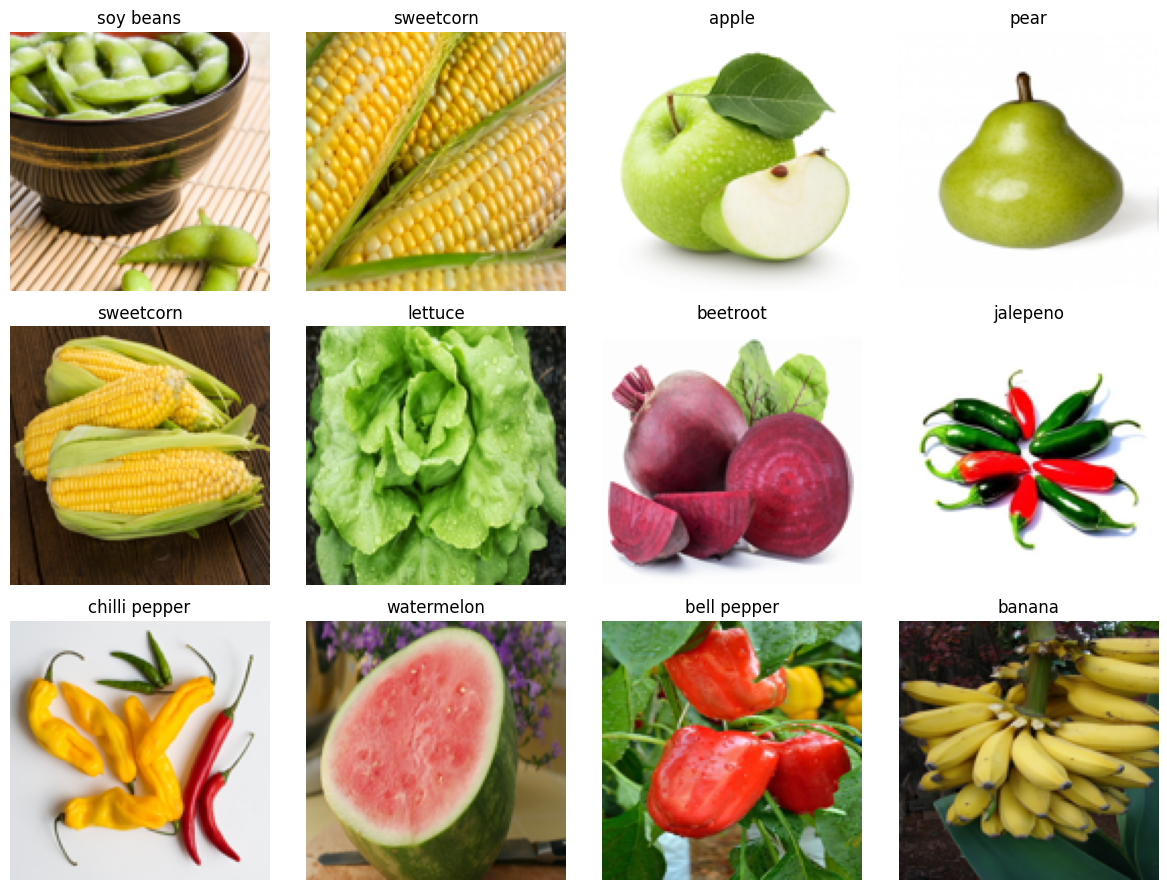

In [3]:
def loaders_for(transform_mode: str, batch_size: int = BATCH_SIZE):
    train_transform = make_transforms(IMAGE_SIZE, mode=transform_mode, normalize=True)
    eval_transform = make_transforms(IMAGE_SIZE, mode="plain", normalize=True)
    return create_dataloaders(
        DATA_ROOT,
        train_transform=train_transform,
        eval_transform=eval_transform,
        batch_size=batch_size,
        num_workers=NUM_WORKERS,
    )

preview_loaders = loaders_for("plain", batch_size=12)
show_image_grid(preview_loaders.train, preview_loaders.class_names, count=12, normalized=True)

## 2. Создание бейзлайна и оценка качества

Пункты 2.a-2.b: обучается сверточный baseline `ResNet-18` из `torchvision` с новой классификационной головой на 36 классов и оценивается качество по выбранным метрикам.

Обучаем baseline `torchvision ResNet-18`, строим графики обучения, classification report и confusion matrix на test split.


torchvision_resnet18_plain: training on cuda


epoch 01/6: train_loss=3.0137, train_acc=0.1551, val_loss=2.8173, val_macro_f1=0.1314


epoch 02/6: train_loss=2.4836, train_acc=0.2501, val_loss=1.8728, val_macro_f1=0.3176


epoch 03/6: train_loss=2.2423, train_acc=0.3178, val_loss=2.2856, val_macro_f1=0.2575


epoch 04/6: train_loss=2.1016, train_acc=0.3624, val_loss=1.7510, val_macro_f1=0.3911


epoch 05/6: train_loss=1.9357, train_acc=0.4151, val_loss=1.5627, val_macro_f1=0.4739


epoch 06/6: train_loss=1.8209, train_acc=0.4433, val_loss=1.4667, val_macro_f1=0.5262


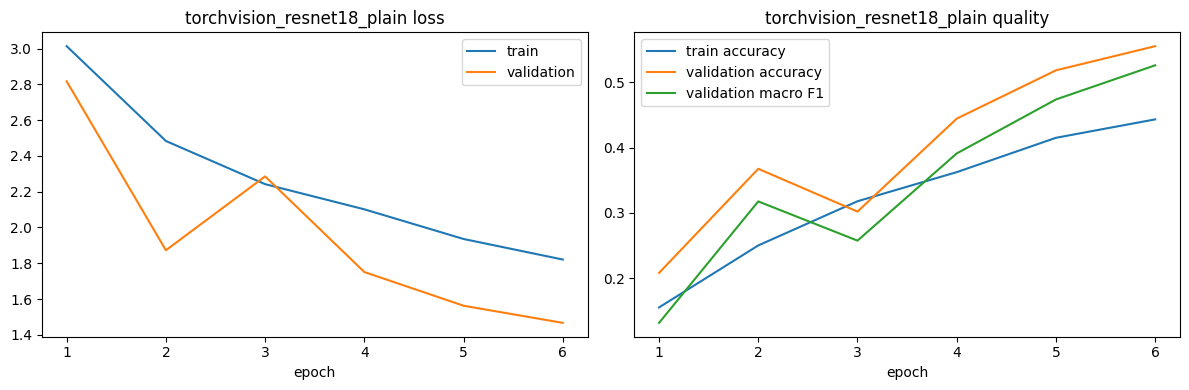

torchvision_resnet18_plain | test classification report
               precision    recall  f1-score   support

        apple       0.50      0.20      0.29        10
       banana       0.00      0.00      0.00         9
     beetroot       0.40      0.20      0.27        10
  bell pepper       0.50      0.20      0.29        10
      cabbage       1.00      0.80      0.89        10
     capsicum       0.67      0.60      0.63        10
       carrot       0.69      0.90      0.78        10
  cauliflower       0.28      1.00      0.43        10
chilli pepper       1.00      0.20      0.33        10
         corn       0.67      0.40      0.50        10
     cucumber       0.58      0.70      0.64        10
     eggplant       0.78      0.70      0.74        10
       garlic       1.00      0.30      0.46        10
       ginger       1.00      0.40      0.57        10
       grapes       0.67      0.60      0.63        10
     jalepeno       0.50      0.20      0.29        10
        

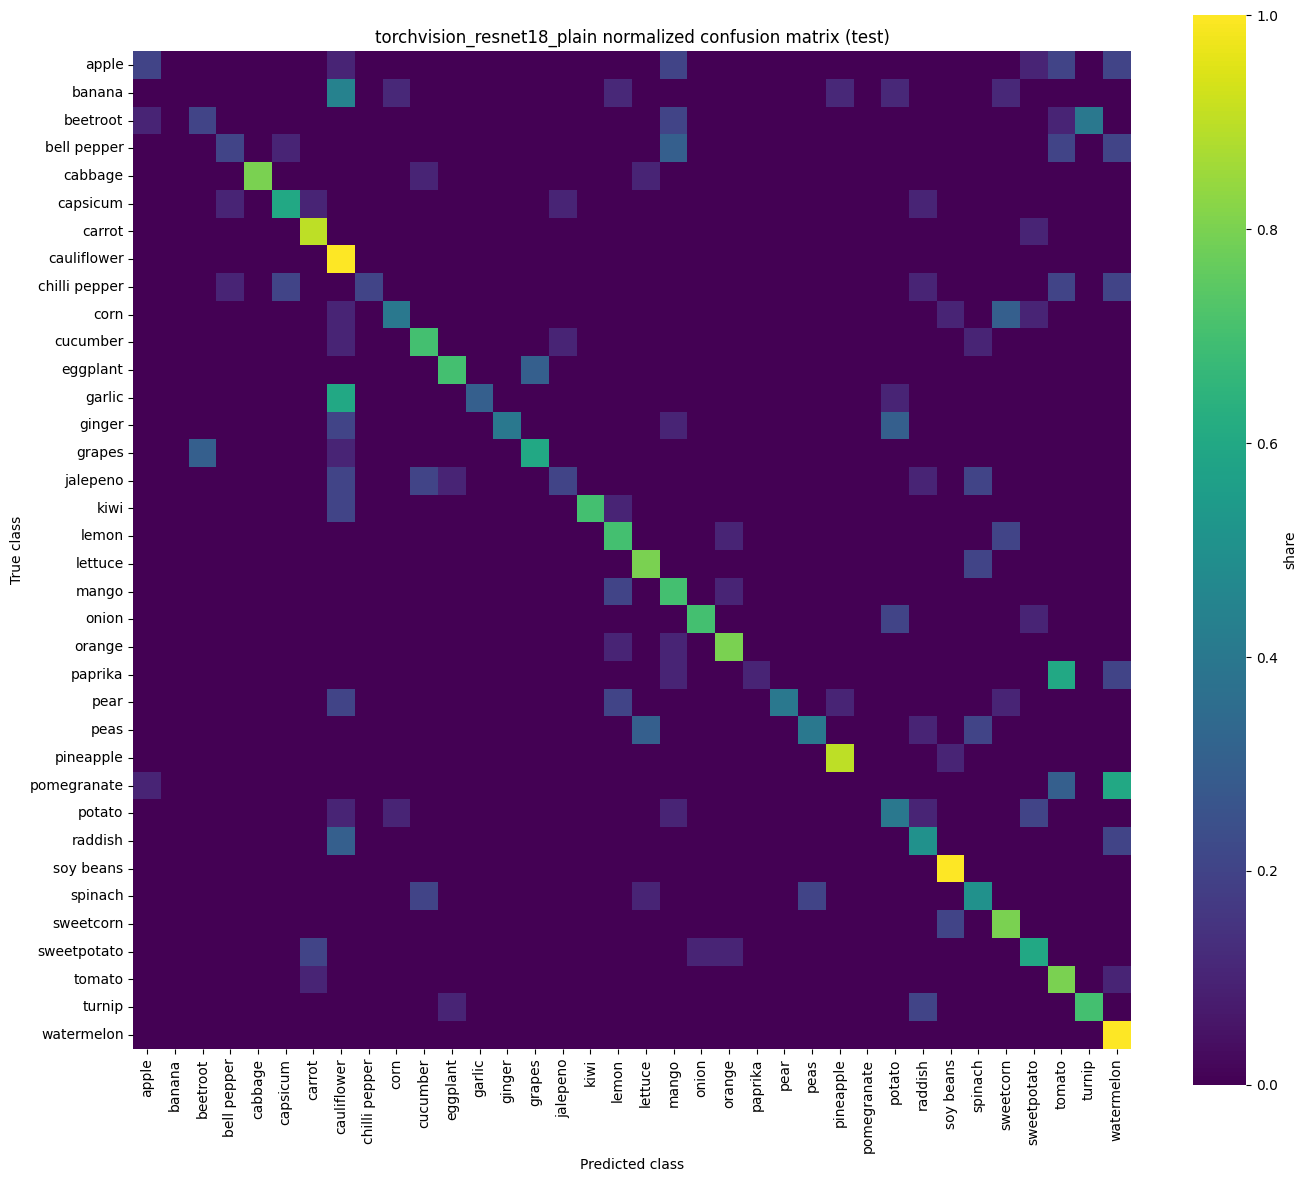

In [4]:
num_classes = len(preview_loaders.class_names)
plain_loaders = loaders_for("plain")

cnn_baseline = fit_classifier(
    create_torchvision_resnet("resnet18", num_classes=num_classes, weights=None),
    name="torchvision_resnet18_plain",
    train_loader=plain_loaders.train,
    val_loader=plain_loaders.val,
    test_loader=plain_loaders.test,
    class_names=plain_loaders.class_names,
    config=RunConfig(
        epochs=BASE_EPOCHS,
        learning_rate=1e-3,
        weight_decay=1e-4,
        scheduler="none",
        fast_dev_run=FAST_DEV_RUN,
        seed=SEED,
    ),
    device=DEVICE,
    output_dir=OUTPUT_DIR,
)

plot_history(cnn_baseline)
print_report(cnn_baseline)
plot_confusion_matrix(cnn_baseline)

## 3. Улучшение бейзлайна

Пункты 3.a-3.g: формулируем и проверяем гипотезы про learning rate, аугментации, scheduler и более глубокую `ResNet-34`; лучшую конфигурацию выбираем по `validation macro F1` и сравниваем с baseline.

Проводим серию CNN-экспериментов, сохраняем результаты и формируем сравнительные таблицы для validation и test split.

In [5]:
cnn_specs = [
    {
        "name": "resnet18_lr_3e-4",
        "model": "resnet18",
        "transform_mode": "plain",
        "learning_rate": 3e-4,
        "weight_decay": 1e-4,
        "scheduler": "none",
        "epochs": BASE_EPOCHS,
    },
    {
        "name": "resnet18_augmented",
        "model": "resnet18",
        "transform_mode": "augmented",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "scheduler": "none",
        "epochs": BASE_EPOCHS,
    },
    {
        "name": "resnet18_augmented_cosine",
        "model": "resnet18",
        "transform_mode": "augmented",
        "learning_rate": 5e-4,
        "weight_decay": 2e-4,
        "scheduler": "cosine",
        "epochs": BASE_EPOCHS + 2,
    },
    {
        "name": "resnet34_augmented_cosine",
        "model": "resnet34",
        "transform_mode": "augmented",
        "learning_rate": 5e-4,
        "weight_decay": 2e-4,
        "scheduler": "cosine",
        "epochs": BASE_EPOCHS + 2,
    },
]

cnn_experiment_records = []
for spec in cnn_specs:
    loaders = loaders_for(spec["transform_mode"])
    result = fit_classifier(
        create_torchvision_resnet(spec["model"], num_classes=num_classes, weights=None),
        name=spec["name"],
        train_loader=loaders.train,
        val_loader=loaders.val,
        test_loader=loaders.test,
        class_names=loaders.class_names,
        config=RunConfig(
            epochs=spec["epochs"],
            learning_rate=spec["learning_rate"],
            weight_decay=spec["weight_decay"],
            scheduler=spec["scheduler"],
            fast_dev_run=FAST_DEV_RUN,
            seed=SEED,
        ),
        device=DEVICE,
        output_dir=OUTPUT_DIR,
    )
    cnn_experiment_records.append({"spec": spec, "result": result})

cnn_hypothesis_results = [record["result"] for record in cnn_experiment_records]
display(summarize_results([cnn_baseline] + cnn_hypothesis_results, split="val"))
display(summarize_results([cnn_baseline] + cnn_hypothesis_results, split="test"))


resnet18_lr_3e-4: training on cuda


epoch 01/6: train_loss=2.7805, train_acc=0.2067, val_loss=2.2322, val_macro_f1=0.3042


epoch 02/6: train_loss=2.1682, train_acc=0.3567, val_loss=1.7221, val_macro_f1=0.4219


epoch 03/6: train_loss=1.8620, train_acc=0.4411, val_loss=1.4331, val_macro_f1=0.5671


epoch 04/6: train_loss=1.6078, train_acc=0.5108, val_loss=1.2683, val_macro_f1=0.5358


...

epoch 06/8: train_loss=1.8913, train_acc=0.4369, val_loss=1.3866, val_macro_f1=0.5647


epoch 07/8: train_loss=1.7070, train_acc=0.4703, val_loss=1.0624, val_macro_f1=0.6740


epoch 08/8: train_loss=1.5300, train_acc=0.5393, val_loss=1.0380, val_macro_f1=0.6926


,model,best_epoch,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top3_accuracy
0,resnet18_augmented_cosine,8,0.757835,0.778634,0.756173,0.749881,0.751196,0.920228
1,resnet18_lr_3e-4,5,0.706553,0.777318,0.704938,0.694787,0.696286,0.888889
2,resnet34_augmented_cosine,8,0.700855,0.741168,0.699383,0.692637,0.694333,0.903134
3,torchvision_resnet18_plain,6,0.555556,0.609002,0.553395,0.526211,0.527891,0.823362
4,resnet18_augmented,4,0.470085,0.486575,0.471296,0.415751,0.416209,0.754986


,model,best_epoch,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top3_accuracy
0,resnet18_augmented_cosine,8,0.760446,0.783664,0.759877,0.754482,0.754842,0.922006
1,resnet34_augmented_cosine,8,0.707521,0.749240,0.706790,0.700658,0.701124,0.905292
2,resnet18_lr_3e-4,5,0.704735,0.776428,0.704630,0.695581,0.695553,0.888579
3,torchvision_resnet18_plain,6,0.554318,0.614090,0.552778,0.526999,0.528467,0.818942
4,resnet18_augmented,4,0.470752,0.484538,0.471605,0.415998,0.415597,0.760446


### 3.c-3.g. Формирование и оценка улучшенного бейзлайна

После проверки гипотез выбираем лучшую конфигурацию, затем выводим ее подробные метрики и графики.

Выбираем лучший CNN baseline по `validation macro F1`, затем выводим его настройки, отчет классификации, историю обучения и confusion matrix.

Best CNN spec:


,name,model,transform_mode,learning_rate,weight_decay,scheduler,epochs
0,resnet18_augmented_cosine,resnet18,augmented,0.0005,0.0002,cosine,8


resnet18_augmented_cosine | test classification report
               precision    recall  f1-score   support

        apple       0.83      0.50      0.62        10
       banana       0.71      0.56      0.62         9
     beetroot       0.77      1.00      0.87        10
  bell pepper       0.75      0.30      0.43        10
      cabbage       1.00      1.00      1.00        10
     capsicum       0.27      0.40      0.32        10
       carrot       1.00      0.90      0.95        10
  cauliflower       1.00      1.00      1.00        10
chilli pepper       0.33      0.40      0.36        10
         corn       0.80      0.40      0.53        10
     cucumber       0.89      0.80      0.84        10
     eggplant       1.00      0.80      0.89        10
       garlic       0.83      1.00      0.91        10
       ginger       0.70      0.70      0.70        10
       grapes       0.90      0.90      0.90        10
     jalepeno       0.73      0.80      0.76        10
         

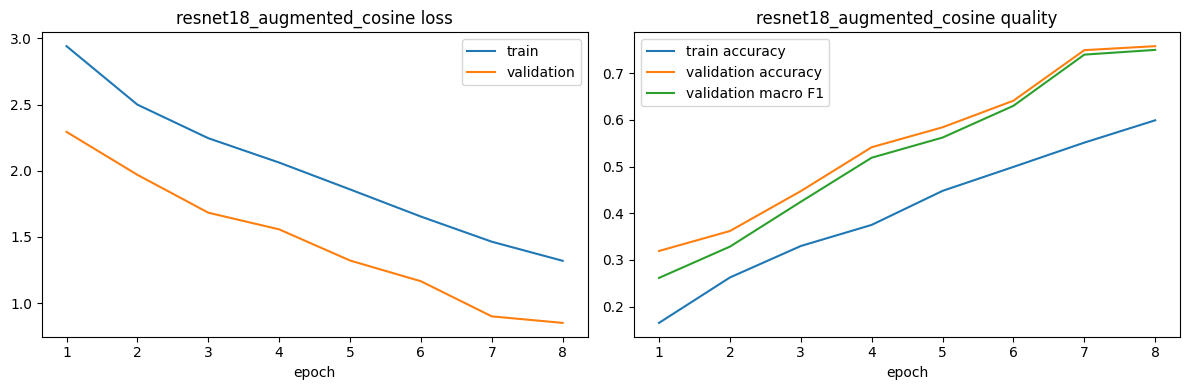

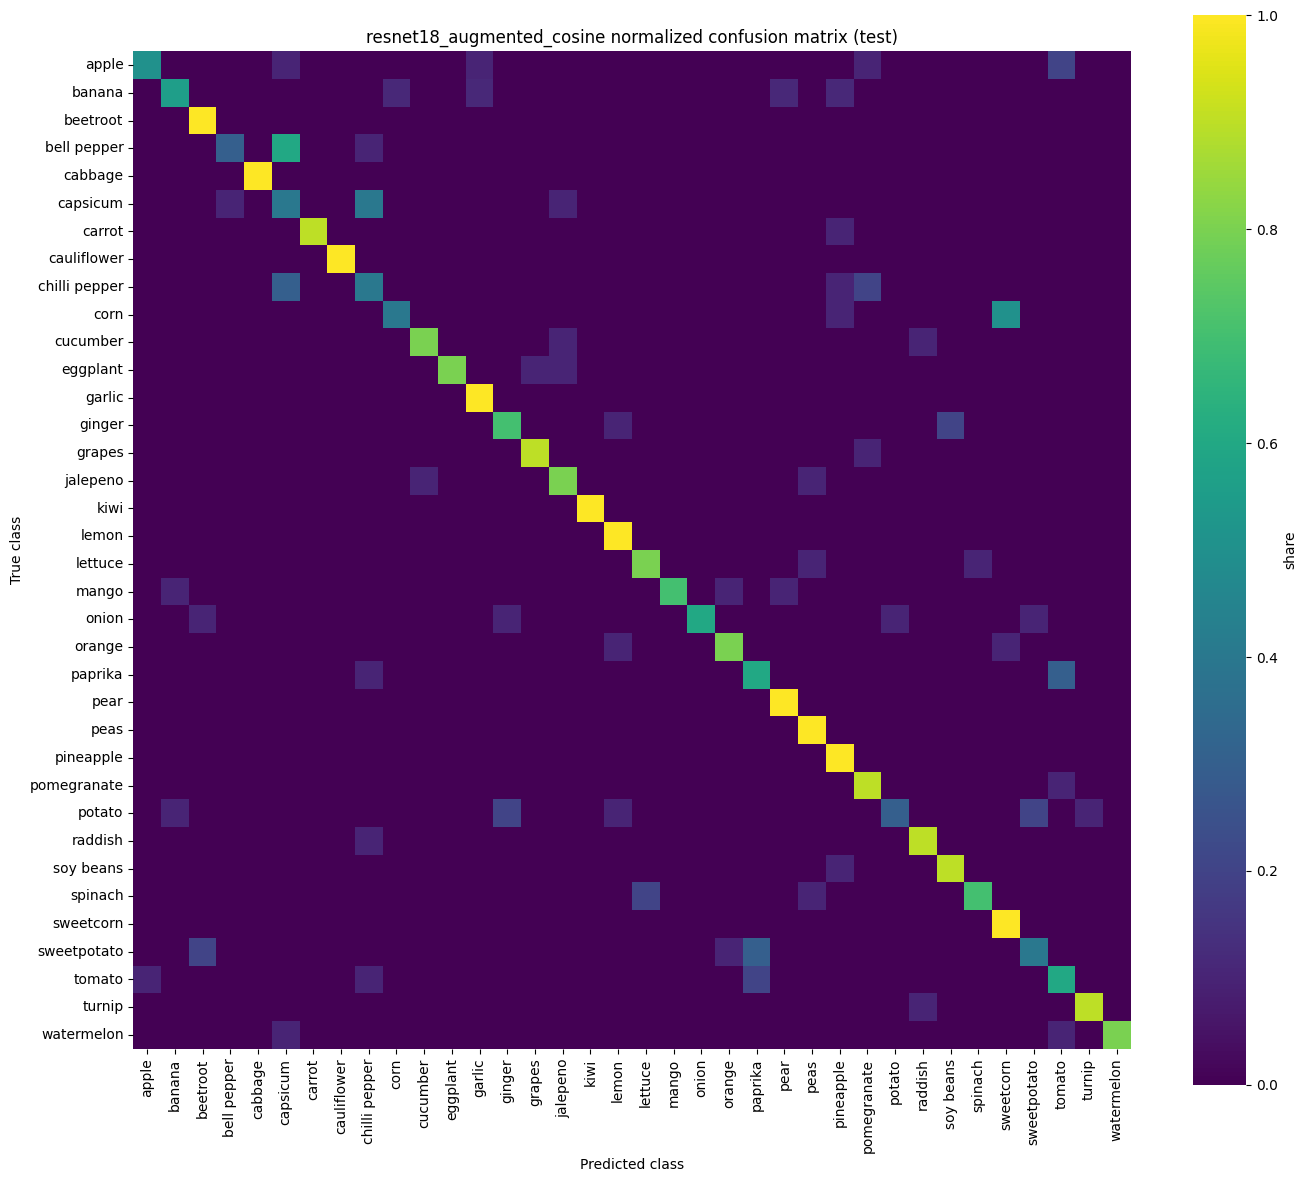

In [6]:
best_record = max(cnn_experiment_records, key=lambda item: item["result"]["val"]["macro_f1"])
best_cnn_spec = best_record["spec"]
best_torchvision_cnn = best_record["result"]

print("Best CNN spec:")
display(pd.DataFrame([best_cnn_spec]))
print_report(best_torchvision_cnn)
plot_history(best_torchvision_cnn)
plot_confusion_matrix(best_torchvision_cnn)

## 4. Имплементация алгоритма машинного обучения

Пункты 4.a-4.j: обучается собственная residual CNN без использования готовой модели `torchvision`, затем к ней применяются настройки улучшенного baseline и выполняется итоговое сравнение.

Обучаем собственную residual CNN в базовом режиме, после чего выводим метрики, графики и confusion matrix.


custom_residual_cnn_plain: training on cuda


epoch 01/6: train_loss=3.0053, train_acc=0.1506, val_loss=2.8941, val_macro_f1=0.1347


epoch 02/6: train_loss=2.5703, train_acc=0.2331, val_loss=1.9978, val_macro_f1=0.3194


epoch 03/6: train_loss=2.3099, train_acc=0.3021, val_loss=2.1404, val_macro_f1=0.3159


epoch 04/6: train_loss=2.2017, train_acc=0.3310, val_loss=1.8948, val_macro_f1=0.3692


epoch 05/6: train_loss=2.0360, train_acc=0.3843, val_loss=1.6819, val_macro_f1=0.4213


epoch 06/6: train_loss=1.9585, train_acc=0.4061, val_loss=1.4856, val_macro_f1=0.5031


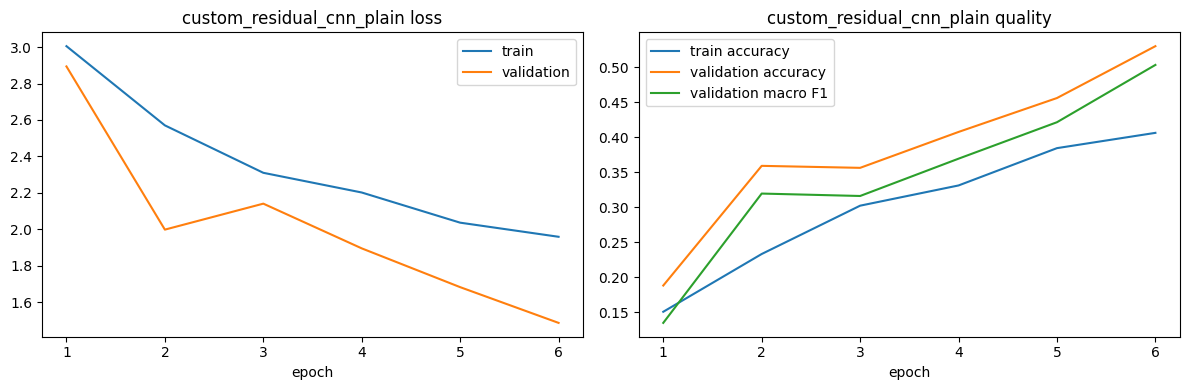

custom_residual_cnn_plain | test classification report
               precision    recall  f1-score   support

        apple       0.00      0.00      0.00        10
       banana       0.75      0.33      0.46         9
     beetroot       0.88      0.70      0.78        10
  bell pepper       0.25      0.10      0.14        10
      cabbage       1.00      0.70      0.82        10
     capsicum       0.29      0.20      0.24        10
       carrot       0.45      0.90      0.60        10
  cauliflower       0.29      1.00      0.45        10
chilli pepper       0.25      0.20      0.22        10
         corn       0.29      0.40      0.33        10
     cucumber       0.83      0.50      0.62        10
     eggplant       1.00      0.20      0.33        10
       garlic       0.50      0.30      0.38        10
       ginger       0.62      0.50      0.56        10
       grapes       0.57      0.80      0.67        10
     jalepeno       0.67      0.20      0.31        10
         

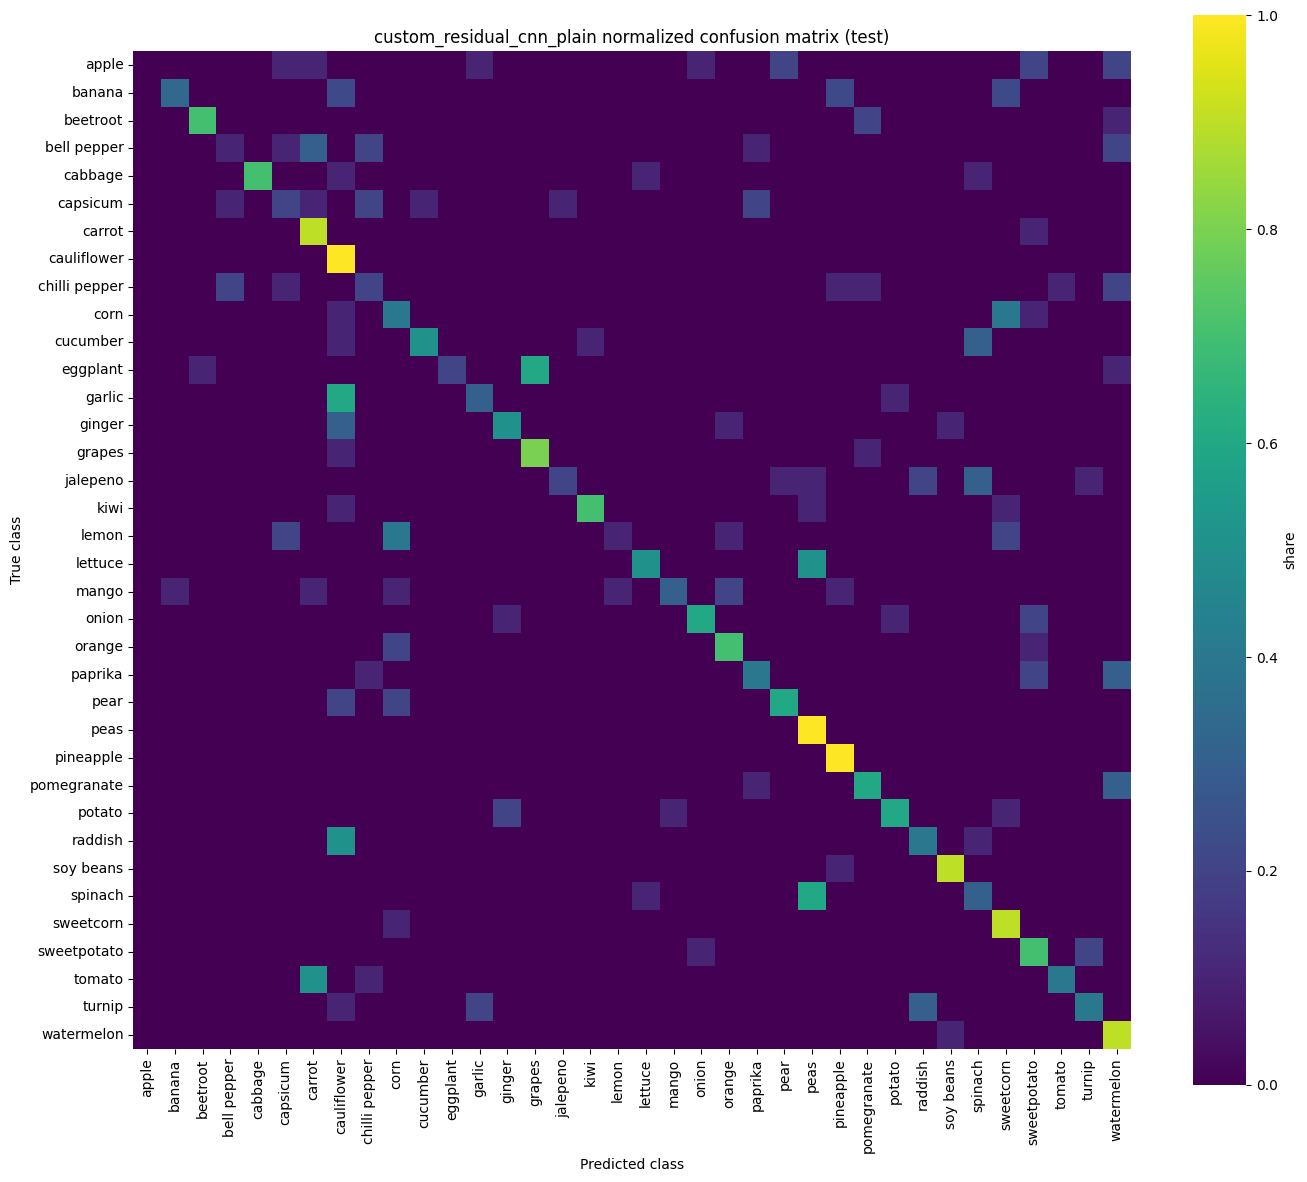

In [7]:
custom_cnn_plain = fit_classifier(
    ProduceResidualCNN(num_classes=num_classes, dropout=0.25),
    name="custom_residual_cnn_plain",
    train_loader=plain_loaders.train,
    val_loader=plain_loaders.val,
    test_loader=plain_loaders.test,
    class_names=plain_loaders.class_names,
    config=RunConfig(
        epochs=BASE_EPOCHS,
        learning_rate=1e-3,
        weight_decay=1e-4,
        scheduler="none",
        fast_dev_run=FAST_DEV_RUN,
        seed=SEED,
    ),
    device=DEVICE,
    output_dir=OUTPUT_DIR,
)

plot_history(custom_cnn_plain)
print_report(custom_cnn_plain)
plot_confusion_matrix(custom_cnn_plain)

Обучаем собственную residual CNN с настройками, выбранными на этапе улучшения baseline.


custom_residual_cnn_improved: training on cuda


epoch 01/8: train_loss=3.0535, train_acc=0.1506, val_loss=2.8530, val_macro_f1=0.2104


epoch 02/8: train_loss=2.6407, train_acc=0.2202, val_loss=2.0636, val_macro_f1=0.2937


epoch 03/8: train_loss=2.4157, train_acc=0.2722, val_loss=2.0125, val_macro_f1=0.3768


epoch 04/8: train_loss=2.2519, train_acc=0.3175, val_loss=1.6807, val_macro_f1=0.4718


epoch 05/8: train_loss=2.1119, train_acc=0.3708, val_loss=1.5432, val_macro_f1=0.5077


epoch 06/8: train_loss=1.9545, train_acc=0.4051, val_loss=1.4325, val_macro_f1=0.4913


epoch 07/8: train_loss=1.8237, train_acc=0.4424, val_loss=1.1562, val_macro_f1=0.7037


epoch 08/8: train_loss=1.7045, train_acc=0.4787, val_loss=1.1645, val_macro_f1=0.6696


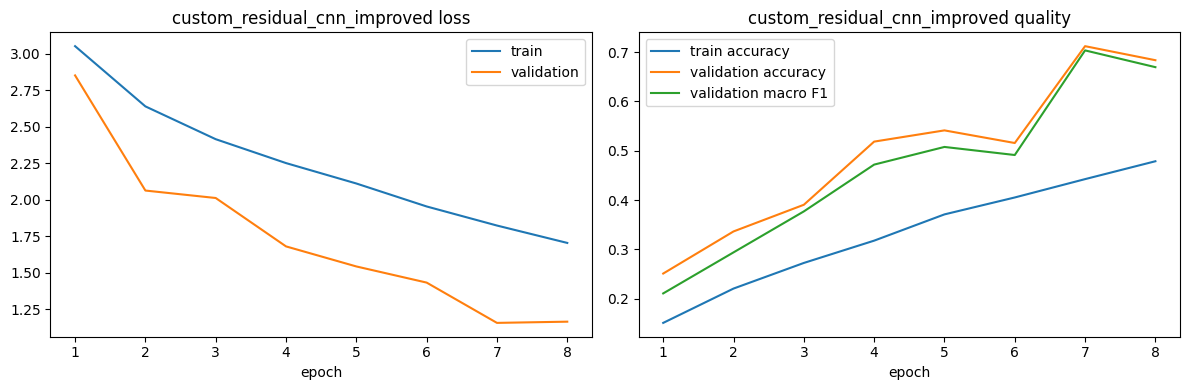

custom_residual_cnn_improved | test classification report
               precision    recall  f1-score   support

        apple       0.56      0.50      0.53        10
       banana       0.67      0.44      0.53         9
     beetroot       0.59      1.00      0.74        10
  bell pepper       0.67      0.20      0.31        10
      cabbage       0.91      1.00      0.95        10
     capsicum       0.21      0.30      0.25        10
       carrot       1.00      0.80      0.89        10
  cauliflower       1.00      0.70      0.82        10
chilli pepper       0.22      0.40      0.29        10
         corn       0.83      0.50      0.62        10
     cucumber       0.67      1.00      0.80        10
     eggplant       1.00      0.80      0.89        10
       garlic       0.69      0.90      0.78        10
       ginger       0.73      0.80      0.76        10
       grapes       0.75      0.90      0.82        10
     jalepeno       0.80      0.40      0.53        10
      

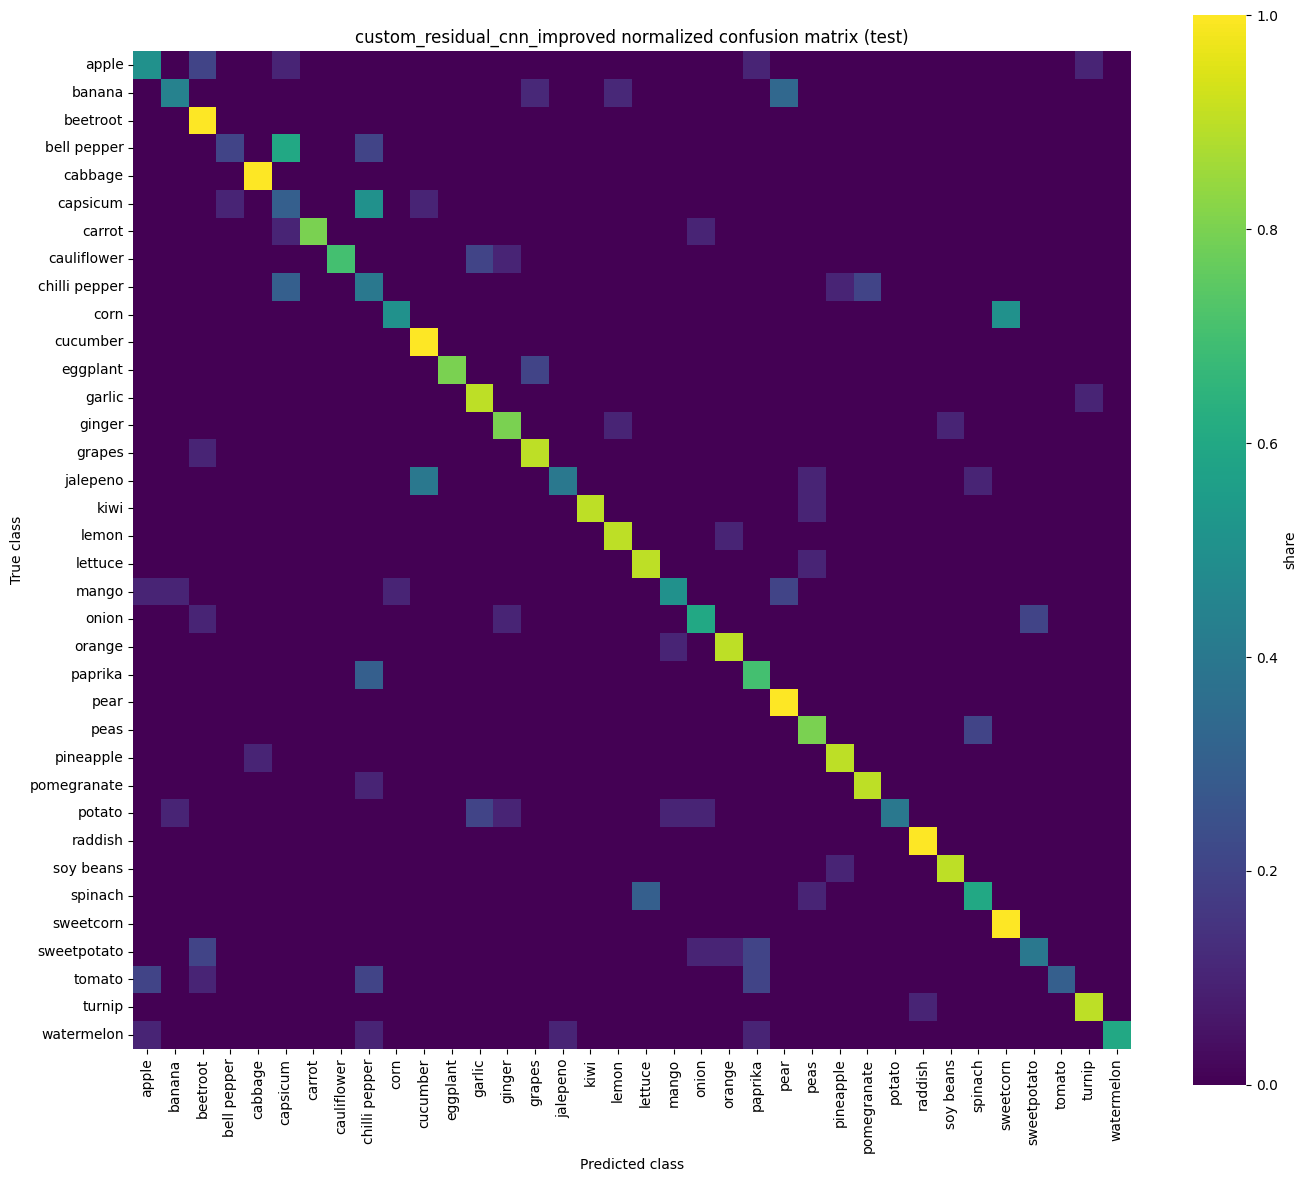

In [8]:
improved_loaders = loaders_for(best_cnn_spec["transform_mode"])
custom_cnn_improved = fit_classifier(
    ProduceResidualCNN(num_classes=num_classes, dropout=0.30),
    name="custom_residual_cnn_improved",
    train_loader=improved_loaders.train,
    val_loader=improved_loaders.val,
    test_loader=improved_loaders.test,
    class_names=improved_loaders.class_names,
    config=RunConfig(
        epochs=best_cnn_spec["epochs"],
        learning_rate=best_cnn_spec["learning_rate"],
        weight_decay=best_cnn_spec["weight_decay"],
        scheduler=best_cnn_spec["scheduler"],
        fast_dev_run=FAST_DEV_RUN,
        seed=SEED,
    ),
    device=DEVICE,
    output_dir=OUTPUT_DIR,
)

plot_history(custom_cnn_improved)
print_report(custom_cnn_improved)
plot_confusion_matrix(custom_cnn_improved)

### 4.d-4.j. Сравнение и выводы

Сравниваются baseline, улучшенный `torchvision` baseline, собственная модель и собственная модель с улучшениями.

Формируем финальную таблицу результатов CNN-моделей на test split и краткий вывод по значениям метрик.

In [9]:
cnn_final_results = [
    cnn_baseline,
    best_torchvision_cnn,
    custom_cnn_plain,
    custom_cnn_improved,
]

display(summarize_results(cnn_final_results, split="test"))
print(make_conclusion(cnn_final_results, split="test"))

,model,best_epoch,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top3_accuracy
0,resnet18_augmented_cosine,8,0.760446,0.783664,0.759877,0.754482,0.754842,0.922006
1,custom_residual_cnn_improved,7,0.715877,0.755418,0.715123,0.708125,0.708612,0.902507
2,torchvision_resnet18_plain,6,0.554318,0.614090,0.552778,0.526999,0.528467,0.818942
3,custom_residual_cnn_plain,6,0.529248,0.574723,0.528704,0.506392,0.506517,0.802228


Лучший результат по test macro F1 показала модель resnet18_augmented_cosine с macro F1=0.7545 и accuracy=0.7604. Разница с наименее успешной конфигурацией в этой таблице составляет 0.2481 по macro F1. Для итогового сравнения важнее macro F1, потому что он одинаково учитывает все 36 классов.
